In [2]:
#初始化ricequant api
import rqdatac

with open("api_key.txt", "r", encoding="utf-8") as f:
    api_key = f.read().strip()
PASSWD = api_key
if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac 初始化成功")
else:
    print("请先填写 PASSWD，再运行本单元")

rqdatac 初始化成功


d:\python-3.9\lib\site-packages\rqdatac\client.py:263: UserWarning: Your account will be expired after  392 days. Please call us at 0755-22676337 to upgrade or purchase or renew your contract.
  warnings.warn("Your account will be expired after  {} days. "


In [3]:
#导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import medcouple
import statsmodels.api as sm


 A 股为数据样本，并且剔除 ST 股票、上市不足两年的股票以及长时间停牌不能交易的个股。样
本数据测试期为近十年数据（2010.1.1-2020.1.1）。由于在不同经济和市场周期阶段内因子表现存在差异，
为了贴近实际投资策略，我们将对不同时间窗口进行因子测试，例如，从现在来看，中期处于经济受到打击
后的复苏阶段，可以以 2008 年金融危机后的市场和新冠疫情爆发后的市场作为回验时间窗口。


In [4]:
START_DATE = "2010-01-01"
END_DATE = "2020-01-01"

#获取A股从2010-1-1开始每月最后一个交易日
trading_dates = rqdatac.get_trading_dates(
    start_date=START_DATE,
    end_date= END_DATE,
    market="cn"
    )

trading_dates = pd.to_datetime(trading_dates)
calendar = pd.DataFrame({"date": trading_dates})
calendar["month"] = calendar["date"].dt.to_period("M")

month_end_dates = (
    calendar
    .groupby("month")["date"]
    .max()
    .reset_index(drop=True)
    )
month_end_dates.head()




0   2010-01-29
1   2010-02-26
2   2010-03-31
3   2010-04-30
4   2010-05-31
Name: date, dtype: datetime64[ns]

In [ ]:
#给定日期，去除st
def adjust_st(date):
    A_share_org = rqdatac.all_instruments(
        type="CS",
        date=date,
        market="cn"
    )['order_book_id']
    mask_st = rqdatac.is_st_stock(A_share_org.to_list(),date,date)
    df_r_st = pd.DataFrame(A_share_org)[(~mask_st.iloc[0]).to_list()]
    return df_r_st





1724

In [ ]:
#给定日期去除停牌
def adjust_suspended(date):
    A_share_org = rqdatac.all_instruments(
        type="CS",
        date=date,
        market="cn"
    )['order_book_id']
    mask_sus = rqdatac.is_suspended(A_share_org.to_list(),date,date)
    df_r_sus = pd.DataFrame(A_share_org)[(~mask_sus.iloc[0]).to_list()]
    return df_r_sus

1811

In [ ]:
#给定日期去除上市不满两年
def adjust_length(d):
    stock_info = rqdatac.all_instruments(
        type="CS",
        date=d,
        market="cn"
    ).copy()
    stock_info["listed_date"] = pd.to_datetime(stock_info["listed_date"])
    date_dt = pd.to_datetime(d)
    stock_info["listed_days"] = (date_dt - stock_info["listed_date"]).dt.days

    stock_info = stock_info[stock_info["listed_days"] >= 365 * 2]

    df_length_2 = pd.DataFrame(stock_info["order_book_id"])
    return df_length_2

1582

In [ ]:
#筛选出符合要求的A股
# 剔除 ST 股票、上市不足两年的股票以及长时间停牌不能交易的个股
def final_A(d):
    ad_st = adjust_st(d)['order_book_id'].tolist()
    ad_sus = adjust_suspended(d)['order_book_id'].tolist()
    ad_length = adjust_length(d)['order_book_id'].tolist()
    
    final_list = list(
        set(ad_st)
        & set(ad_sus)
        & set(ad_length)
    )
    return final_list


1373

先算BP

In [10]:
BP_list = []

for d in month_end_dates:
    A_share = final_A(d)
    d_BP = rqdatac.get_factor(
        order_book_ids = A_share,
        factor='book_to_market_ratio_lf',
        start_date = d,
        end_date = d
    ).reset_index()
    BP_list.append(d_BP)


In [11]:
df_BP = pd.concat(BP_list, ignore_index=True)

In [12]:
len(df_BP[df_BP['book_to_market_ratio_lf'] <= 0])

313

用调整boxplot方法清洗数据

In [13]:
#去掉负值
df_BP = df_BP[df_BP['book_to_market_ratio_lf'] > 0].copy()

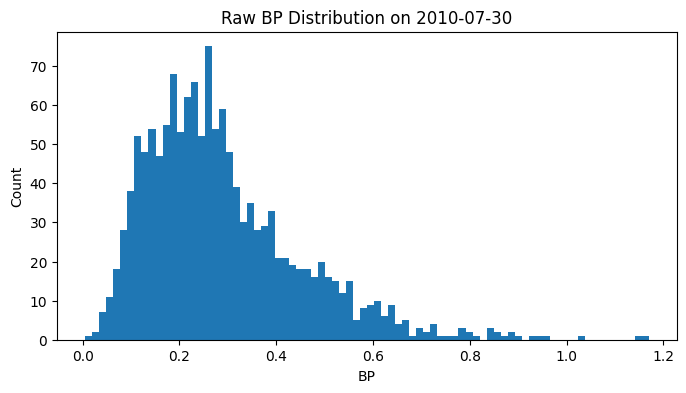

In [ ]:
#这里假设BP分布大致一样，选一天看BP分布
cross_section = df_BP[df_BP["date"] ==month_end_dates[0]]

plt.figure(figsize=(8, 4))
plt.hist(cross_section['book_to_market_ratio_lf'], bins=80)
plt.title(f"Raw BP Distribution on {month_end_dates[0].date()}")
plt.xlabel("BP")
plt.ylabel("Count")
plt.show()

发现明显右偏分布，使用调整boxplot

In [15]:
#调整boxplot函数
def adjust_boxplot(cro_sec):

    x = pd.to_numeric(cro_sec, errors="coerce")
    x = x.replace([np.inf, -np.inf], np.nan)
    x = x.dropna()
    md = x.median()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    mc = medcouple(x.values)

    if mc >= 0:
        l = q1 - 1.5 * np.exp(-3.5 * mc) * iqr
        u = q3 + 1.5 * np.exp(3.5 * mc) * iqr
    else:
        l = q1 - 1.5 * np.exp(-4 * mc) * iqr
        u = q3 + 1.5 * np.exp(4 * mc) * iqr
    cro_sec_clip = cro_sec.clip(lower=l, upper=u)

    return cro_sec_clip

    
    
    

因子标准化

In [16]:
#zscore标准化函数
def z_score(cro_sec):
    mean = cro_sec.mean()
    std = cro_sec.std()
    z = (cro_sec - mean)/std
    return z


In [17]:
df_BP["BP_winsorized"] = (
    df_BP
    .groupby("date")["book_to_market_ratio_lf"]
    .transform(adjust_boxplot)
)

df_BP["BP_zscore"] = (
    df_BP
    .groupby("date")["BP_winsorized"]
    .transform(z_score)
)
df_BP.head()



,order_book_id,date,book_to_market_ratio_lf,BP_winsorized,BP_zscore
0,600019.XSHG,2010-01-29,0.699812,0.699812,3.565202
1,601007.XSHG,2010-01-29,0.381301,0.381301,1.029057
2,600199.XSHG,2010-01-29,0.148769,0.148769,-0.822482
3,601607.XSHG,2010-01-29,0.203867,0.203867,-0.383757
4,000792.XSHE,2010-01-29,0.066589,0.066589,-1.476836


行业中性

In [19]:
#获取对应股票特定日期的申万一级名称
def ind(date):
    stock_ids = df_BP[df_BP['date']==date]["order_book_id"].dropna().unique().tolist()
    industry_df = rqdatac.get_instrument_industry(stock_ids, source='sws', level=1,date=date).reset_index()
    industry_df = industry_df.rename(columns={
        "first_industry_code": "sw_l1_code",
        "first_industry_name": "sw_l1_name"
    })
    industry_df['date'] = date
    return industry_df

In [20]:
ind_date = []
for d in month_end_dates:
    industry_df = ind(d)
    ind_date.append(industry_df)
    



In [21]:
industry_panel = pd.concat(ind_date)
len(industry_panel)

255629

In [23]:
df_BP_final = pd.merge(df_BP,industry_panel,how='left',on=['order_book_id','date'])

In [24]:
df_BP_final.head()

,order_book_id,date,book_to_market_ratio_lf,BP_winsorized,BP_zscore,sw_l1_code,sw_l1_name
0,600019.XSHG,2010-01-29,0.699812,0.699812,3.565202,801040.INDX,黑色金属
1,601007.XSHG,2010-01-29,0.381301,0.381301,1.029057,801210.INDX,餐饮旅游
2,600199.XSHG,2010-01-29,0.148769,0.148769,-0.822482,801120.INDX,食品饮料
3,601607.XSHG,2010-01-29,0.203867,0.203867,-0.383757,801150.INDX,医药生物
4,000792.XSHE,2010-01-29,0.066589,0.066589,-1.476836,801030.INDX,化工


In [26]:
df_BP_final["BP_industry_mean"] = (
    df_BP_final
    .groupby(["date", "sw_l1_name"])["BP_zscore"]
    .transform("mean")
)

df_BP_final["BP_industry_neutral"] = (
    df_BP_final["BP_zscore"] - df_BP_final["BP_industry_mean"]
)
df_BP_final.head()

,order_book_id,date,book_to_market_ratio_lf,BP_winsorized,BP_zscore,sw_l1_code,sw_l1_name,BP_industry_mean,BP_industry_neutral
0,600019.XSHG,2010-01-29,0.699812,0.699812,3.565202,801040.INDX,黑色金属,1.715501,1.849700
1,601007.XSHG,2010-01-29,0.381301,0.381301,1.029057,801210.INDX,餐饮旅游,-0.265411,1.294468
2,600199.XSHG,2010-01-29,0.148769,0.148769,-0.822482,801120.INDX,食品饮料,-0.522013,-0.300469
3,601607.XSHG,2010-01-29,0.203867,0.203867,-0.383757,801150.INDX,医药生物,-0.463890,0.080133
4,000792.XSHE,2010-01-29,0.066589,0.066589,-1.476836,801030.INDX,化工,0.050494,-1.527330


In [27]:
check_std = (
    df_BP_final
    .groupby("date")
    .agg(
        bp_z_std=("BP_zscore", "std"),
        neutral_std=("BP_industry_neutral", "std")
    )
)

print(check_std.describe())

           bp_z_std  neutral_std
count  1.200000e+02   120.000000
mean   1.000000e+00     0.870000
std    6.211549e-16     0.023302
min    1.000000e+00     0.819085
25%    1.000000e+00     0.852228
50%    1.000000e+00     0.871112
75%    1.000000e+00     0.885002
max    1.000000e+00     0.920382


In [28]:
#再对行业中性化后的截面做zscore标准化
df_BP_final["BP_industry_neutral_z"] = (
    df_BP_final
    .groupby("date")["BP_industry_neutral"]
    .transform(z_score)
)

市值中性化


In [29]:
#获取对应日期对应股票的市值
def get_cap(d):
    stocks = df_BP_final[df_BP_final['date']==d]['order_book_id'].to_list()
    cap = rqdatac.get_factor(
        order_book_ids=stocks,
        factor = 'market_cap_3',
        start_date=d,
        end_date=d
    )
    return cap




In [30]:
cap_list = []
for d in month_end_dates:
    cap = get_cap(d).reset_index()
    cap_list.append(cap)



In [31]:
df_cap = pd.concat(cap_list)


In [32]:
#调整cap数据，log,缩尾，zscore标准化
df_cap["market_cap_log"] = np.log(df_cap['market_cap_3'])
def winsorize_1_99(x):
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)
    return x.clip(lower=lower, upper=upper)

df_cap["log_cap_winsorized"] = (
    df_cap
    .groupby("date")["market_cap_log"]
    .transform(winsorize_1_99)
)
df_cap["log_cap_winsorized_z"] = (
    df_cap
    .groupby("date")["log_cap_winsorized"]
    .transform(z_score)
)


In [33]:
df_cap


,order_book_id,date,market_cap_3,market_cap_log,log_cap_winsorized,log_cap_winsorized_z
0,600019.XSHG,2010-01-29,1.327410e+11,25.611665,25.611665,3.089057
1,601007.XSHG,2010-01-29,2.511000e+09,21.643947,21.643947,-0.788248
2,601607.XSHG,2010-01-29,8.765262e+09,22.894062,22.894062,0.433381
3,600199.XSHG,2010-01-29,4.187187e+09,22.155295,22.155295,-0.288552
4,000792.XSHE,2010-01-29,4.106392e+10,24.438396,24.438396,1.942523
...,...,...,...,...,...,...
3287,300124.XSHE,2019-12-31,5.309419e+10,24.695333,24.695333,2.026039
3288,002903.XSHE,2019-12-31,2.193000e+09,21.508536,21.508536,-1.056200
3289,300397.XSHE,2019-12-31,7.082400e+09,22.680879,22.680879,0.077678
3290,002454.XSHE,2019-12-31,3.061192e+09,21.842070,21.842070,-0.733610


In [34]:
#合并两个表
df_BP_cap = df_BP_final.merge(
    df_cap[["date", "order_book_id", "log_cap_winsorized_z"]],
    on=["date", "order_book_id"],
    how="left"
)

In [35]:
#行业市值中性化
def neutralize_industry_cap_one_month(df_month):
    valid = df_month[[
            "BP_zscore",
            "log_cap_winsorized_z",
            "sw_l1_name"]]
    y = valid["BP_zscore"].astype(float)
    # 行业哑变量
    industry_dummies = pd.get_dummies(
        valid["sw_l1_name"],
        prefix="ind",
        drop_first=True
    ).astype(float)
    # 市值控制变量 + 行业哑变量
    X = pd.concat(
        [
            valid[["log_cap_winsorized_z"]].astype(float),
            industry_dummies
        ],
        axis=1
    )
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    df_month.loc[valid.index, "BP_neutral"] = model.resid
    return df_month
df_BP_both_neutral = df_BP_cap.groupby('date', group_keys=False).apply(neutralize_industry_cap_one_month)




C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\2177388971.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_BP_both_neutral = df_BP_cap.groupby('date', group_keys=False).apply(neutralize_industry_cap_one_month)


In [36]:
df_BP_both_neutral["BP_neutral_z"] = (
    df_BP_both_neutral
    .groupby("date")["BP_neutral"]
    .transform(z_score)
)

因子有效性检验，用WSL和RLM

In [38]:
#先获得月末收盘价（前复权）
price = []
for d in month_end_dates:
    stocks = df_BP_both_neutral[df_BP_both_neutral['date'] == d]['order_book_id'].to_list()
    df_price = rqdatac.get_price(
        stocks,
        start_date=d,
        end_date = d,
        fields = 'close',
        adjust_type='pre'
    )
    price.append(df_price)



In [39]:
price1 = []
for i in range(len(month_end_dates)):
    if i == len(month_end_dates)-1:
        continue
    d = month_end_dates[i]
    d1 = month_end_dates[i+1]
    stocks = df_BP_both_neutral[df_BP_both_neutral['date'] == d]['order_book_id'].to_list()
    df_price1 = rqdatac.get_price(
        stocks,
        start_date=d1,
        end_date = d1,
        fields = 'close',
        adjust_type='pre'
    ).reset_index()
    df_price1["date"] = d
    df_price1["next_date"] = d1
    price1.append(df_price1)

In [40]:
df_price = pd.concat(price).reset_index()

In [41]:
df_price1 = pd.concat(price1)
df_price1.rename(columns={"close": "next_close"}, inplace=True)

In [42]:
df_price_total = pd.merge(
    df_price,
    df_price1,
    how='left',
    on=['order_book_id','date']
)

In [44]:
df = pd.merge(
    df_BP_both_neutral[['order_book_id','date','BP_industry_neutral_z','BP_neutral_z']],
    df_price_total,
    how='left',
    on=['order_book_id','date']
)

In [45]:
df.dropna(inplace=True)
df['next_ret'] = df['next_close']/df['close'] -1
df["market_ret_equal"] = (
    df
    .groupby("date")["next_ret"]
    .transform("mean")
)

df["next_excess_ret"] = df["next_ret"] - df["market_ret_equal"]

In [46]:
#添加上后续可能用到的列或因子值
df = df.merge(df_cap[['order_book_id','date','market_cap_3']], how='left', on=['order_book_id','date'])
df = df.merge(df_BP[['order_book_id','date','BP_zscore']], how='left', on=['order_book_id','date'])

In [ ]:
#IC,ranked IC, IR函数
def ic_result(df_month, factor):
    ic = df_month[factor].corr(df_month['next_ret'])
    rank_ic = df_month[factor].corr(df_month['next_ret'],method='spearman')
    return pd.Series({
        "IC": ic,
        "RankIC": rank_ic,
    })
BP_ori = df.groupby('date').apply(ic_result,factor='BP_zscore').reset_index()
BP_ind = df.groupby('date').apply(ic_result,factor='BP_industry_neutral_z').reset_index()
BP_both = df.groupby('date').apply(ic_result,factor='BP_neutral_z').reset_index()



C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\504589932.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  BP_ori = df.groupby('date').apply(ic_result,factor='BP_zscore').reset_index()
C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\504589932.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  BP_ind = df.groupby('date').apply(ic_result,factor='BP_industry_neutral_z').reset_index()
C:\Users\shenh\AppD

In [100]:
# =========================
# IC / RankIC 汇总
# =========================

def summarize_ic_result(ic_df):
    ic = ic_df["IC"].dropna()
    rank_ic = ic_df["RankIC"].dropna()

    return pd.Series({
        "IC_mean": ic.mean(),
        "IC_std": ic.std(),
        "ICIR": ic.mean() / ic.std(),
        "IC_t": ic.mean() / (ic.std() / np.sqrt(len(ic))),
        "IC_positive_ratio": (ic > 0).mean(),

        "RankIC_mean": rank_ic.mean(),
        "RankIC_std": rank_ic.std(),
        "RankICIR": rank_ic.mean() / rank_ic.std(),
        "RankIC_t": rank_ic.mean() / (rank_ic.std() / np.sqrt(len(rank_ic))),
        "RankIC_positive_ratio": (rank_ic > 0).mean(),
    })


ic_summary = pd.DataFrame({
    "BP_ori": summarize_ic_result(BP_ori),
    "BP_ind": summarize_ic_result(BP_ind),
    "BP_both": summarize_ic_result(BP_both),
}).T

ic_summary

,IC_mean,IC_std,ICIR,IC_t,IC_positive_ratio,RankIC_mean,RankIC_std,RankICIR,RankIC_t,RankIC_positive_ratio
BP_ori,0.012763,0.150268,0.084938,0.926564,0.495798,0.036067,0.162442,0.222028,2.422044,0.571429
BP_ind,0.019295,0.100340,0.192292,2.097654,0.521008,0.038976,0.104511,0.372938,4.068277,0.605042
BP_both,0.022334,0.092429,0.241631,2.635884,0.529412,0.042624,0.097158,0.438710,4.785761,0.613445


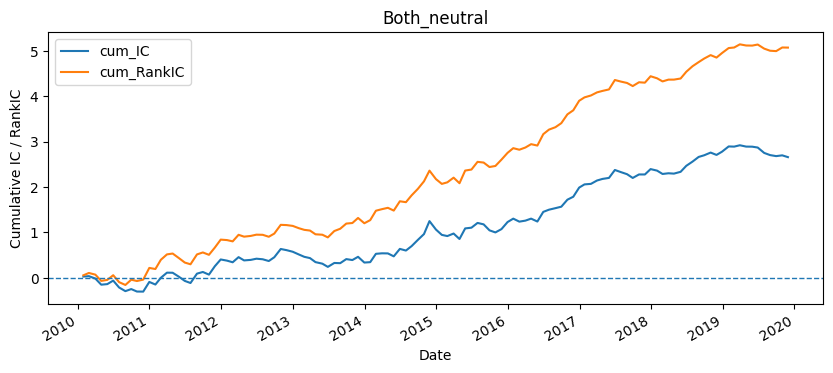

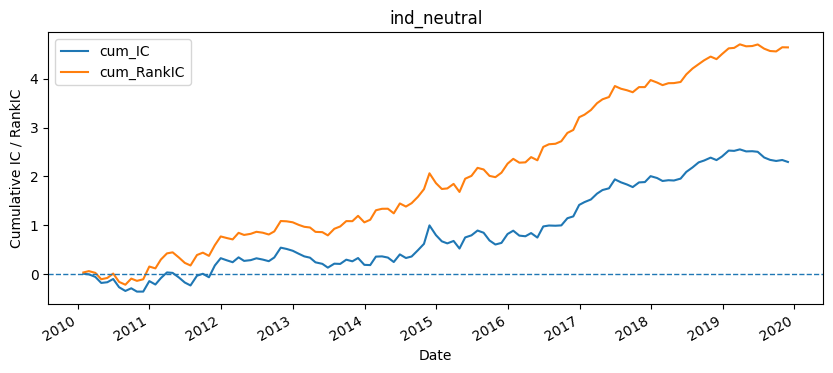

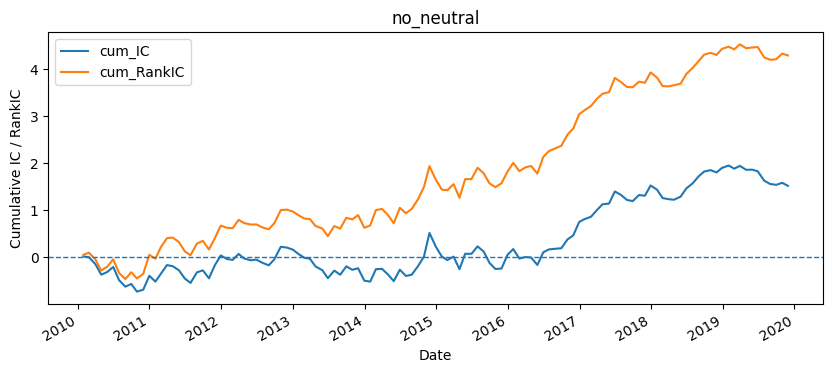

In [110]:
#画IC和RankIC累计图
def plot_cumulative_ic(ic_df, title=None, save_path=None):
    data = ic_df.copy()
    data["date"] = pd.to_datetime(data["date"])
    data = data.sort_values("date")

    data["cum_IC"] = data["IC"].cumsum()
    data["cum_RankIC"] = data["RankIC"].cumsum()

    ax = data.plot(
        x="date",
        y=["cum_IC", "cum_RankIC"],
        figsize=(10, 4),
        title=title
    )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative IC / RankIC")

    fig = ax.get_figure()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

plot_cumulative_ic(BP_both,'Both_neutral','neutral_cum_ic.png')
plot_cumulative_ic(BP_ind,'ind_neutral','ind_neu_cum_ic.png')
plot_cumulative_ic(BP_ori,'no_neutral','ori_cum_ic.png')

In [49]:
#WLS
def wls_result(df_month, factor):
    data = df_month.dropna(
        subset=[factor, "next_excess_ret", "market_cap_3"]
    ).copy()

    data = data[data["market_cap_3"] > 0].copy()

    y = data["next_excess_ret"].astype(float)

    X = data[[factor]].astype(float)
    X = sm.add_constant(X)

    weights = np.sqrt(data["market_cap_3"].astype(float))
    weights = weights / weights.mean()

    model = sm.WLS(y, X, weights=weights).fit()

    return pd.Series({
        "factor_return": model.params[factor],
        "t_value": model.tvalues[factor],
        "r2": model.rsquared,
        "n": len(data)
    })
WLS_ori = df.groupby("date").apply(wls_result, factor="BP_zscore").reset_index()
WLS_ind = df.groupby("date").apply(wls_result, factor="BP_industry_neutral_z").reset_index()
WLS_both = df.groupby("date").apply(wls_result, factor="BP_neutral_z").reset_index()


C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\41207809.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  WLS_ori = df.groupby("date").apply(wls_result, factor="BP_zscore").reset_index()
C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\41207809.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  WLS_ind = df.groupby("date").apply(wls_result, factor="BP_industry_neutral_z").reset_index()
C:\Users\shenh

In [ ]:
# RLM
def rlm_result(df_month, factor):
    data = df_month.dropna(
        subset=[factor, "next_excess_ret"]
    ).copy()

    if len(data) < 30:
        return pd.Series({
            "factor_return": np.nan,
            "t_value": np.nan,
            "n": len(data)
        })

    y = data["next_excess_ret"].astype(float)

    X = data[[factor]].astype(float)
    X = sm.add_constant(X)

    model = sm.RLM(
        y,
        X,
        M=sm.robust.norms.HuberT()
    ).fit(maxiter=100)

    return pd.Series({
        "factor_return": model.params[factor],
        "t_value": model.tvalues[factor],
        "n": len(data)
    })
RLM_ori = df.groupby("date").apply(rlm_result, factor="BP_zscore").reset_index()
RLM_ind = df.groupby("date").apply(rlm_result, factor="BP_industry_neutral_z").reset_index()
RLM_both = df.groupby("date").apply(rlm_result, factor="BP_neutral_z").reset_index()


C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\888936305.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  RLM_ori = df.groupby("date").apply(rlm_result, factor="BP_zscore").reset_index()
C:\Users\shenh\AppData\Local\Temp\ipykernel_8148\888936305.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  RLM_ind = df.groupby("date").apply(rlm_result, factor="BP_industry_neutral_z").reset_index()
C:\Users\she

In [ ]:
#t值总结
def summarize_regression_result(reg_df):
    t_value = reg_df["t_value"].dropna()

    return pd.Series({
        "t_value_mean": t_value.mean(),
        't_value_std': t_value.std(),
        "t_value_positive_ratio": (t_value > 0).mean(),
    })

reg_summary = pd.DataFrame({
    "WLS_ori": summarize_regression_result(WLS_ori),
    "WLS_ind": summarize_regression_result(WLS_ind),
    "WLS_both": summarize_regression_result(WLS_both),
    "RLM_ori": summarize_regression_result(RLM_ori),
    "RLM_ind": summarize_regression_result(RLM_ind),
    "RLM_both": summarize_regression_result(RLM_both),
}).T
reg_summary

,t_value_mean,t_value_std,t_value_positive_ratio
WLS_ori,0.633039,9.272162,0.470588
WLS_ind,0.830993,6.046488,0.504202
WLS_both,0.872630,5.422537,0.537815
RLM_ori,1.475989,7.920467,0.571429
RLM_ind,1.598191,5.145661,0.588235
RLM_both,1.686382,4.693939,0.588235


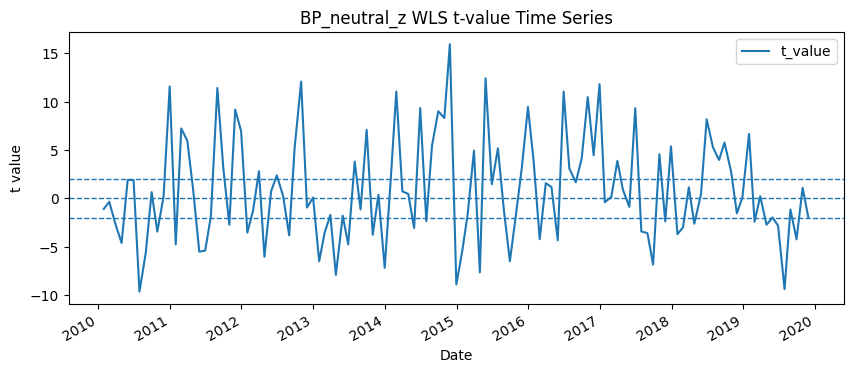

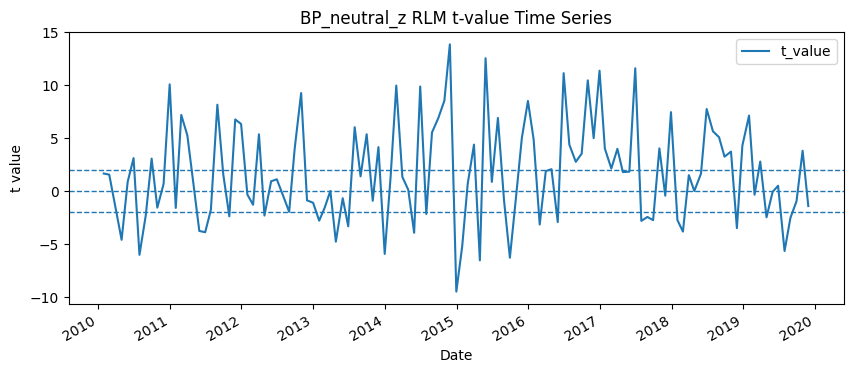

In [115]:
#t值时序图
def plot_t_value(reg_df, title=None, save_path=None):
    data = reg_df.copy()
    data["date"] = pd.to_datetime(data["date"])
    data = data.sort_values("date")

    ax = data.plot(
        x="date",
        y="t_value",
        figsize=(10, 4),
        title=title
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axhline(2, linestyle="--", linewidth=1)
    ax.axhline(-2, linestyle="--", linewidth=1)

    ax.set_xlabel("Date")
    ax.set_ylabel("t value")

    fig = ax.get_figure()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
plot_t_value(
    WLS_both,
    title="BP_neutral_z WLS t-value Time Series",
    save_path='BP_neutral_z_WLS_t_Time_Series.png'
)
plot_t_value(
    RLM_both,
    title="BP_neutral_z RLM t-value Time Series",
    save_path='BP_neutral_z_RLM_t_Time_Series'
)

In [51]:
#因子分层回测
#先分组
ret_col = "next_ret"
def assign_quantile_group(x, n_groups=5):
    """
    对单个月截面的因子值分组。
    因子值越大，组号越大。
    """
    return pd.qcut(
            x,
            q=n_groups,
            labels=False,
            duplicates="drop"
        ) + 1

def group_n_return(factor_col):

    df[f'group_{factor_col}'] = df.groupby("date")[factor_col].transform(lambda x: assign_quantile_group(x, n_groups=5))
    group_ret = (
        df
        .groupby(["date", f'group_{factor_col}'])[ret_col]
        .mean()
        .reset_index()
    )
    return group_ret

ori =  group_n_return('BP_zscore')
ind =  group_n_return('BP_industry_neutral_z')
neutral = group_n_return('BP_neutral_z')




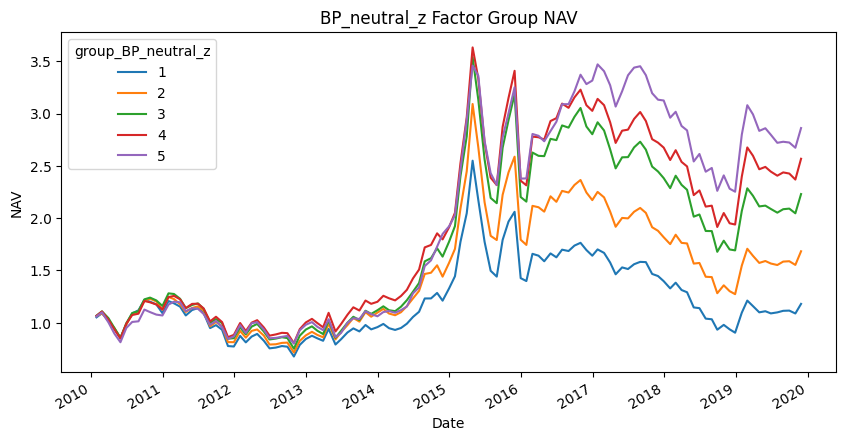

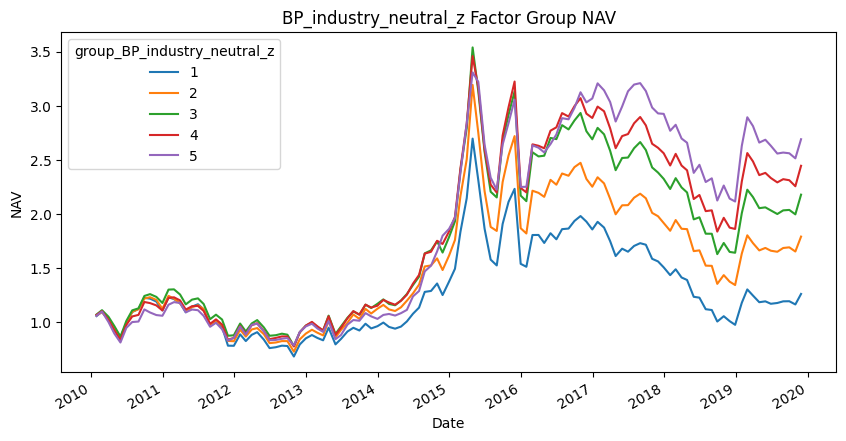

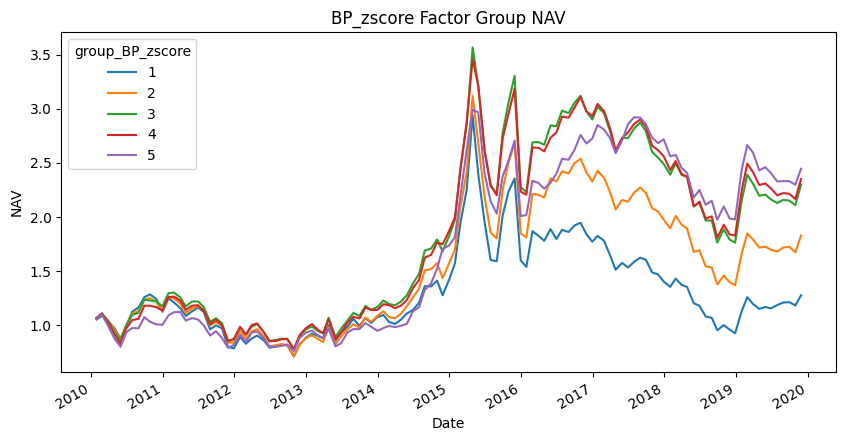

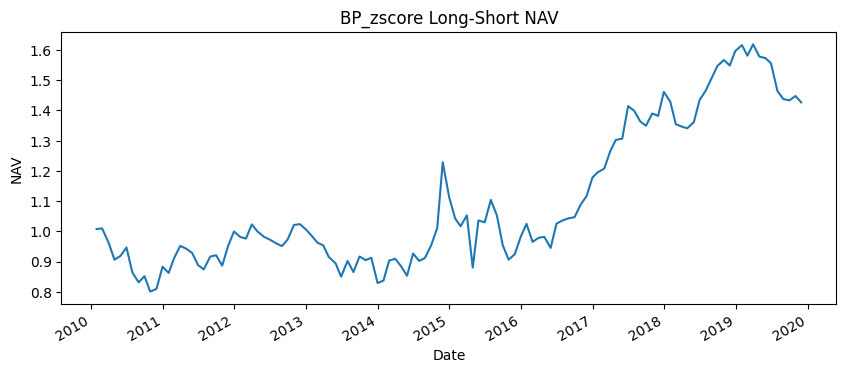

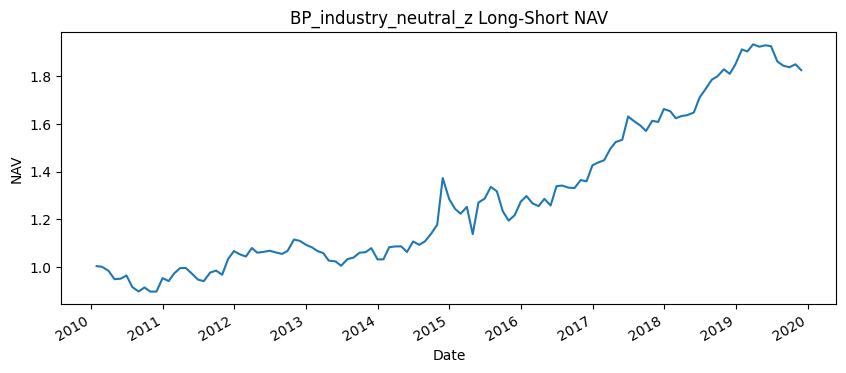

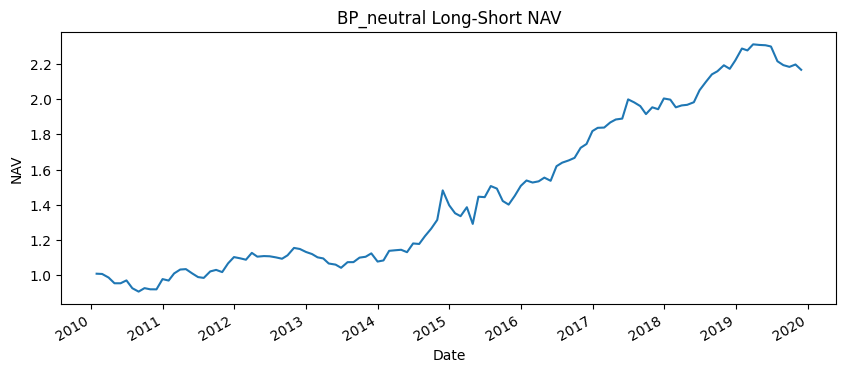

In [113]:
# 分层净值和多空净值
def plot_nav(factor_col, df_group,save_path=None):
    _pivot = df_group.pivot(
        index="date",
        columns=f'group_{factor_col}',
        values=ret_col
    ).sort_index()
    _nav = (1 + _pivot).cumprod()

    ax = _nav.plot(
        figsize=(10, 5),
        title=f"{factor_col} Factor Group NAV"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("NAV")

    fig = ax.get_figure()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()

    return _pivot, _nav
n_pivot,n_nav = plot_nav('BP_neutral_z',neutral,'neutral_nav.png')
ind_pivot,ind_nav = plot_nav('BP_industry_neutral_z',ind,'ind_nav.png')
ori_pivot,ori_nav = plot_nav('BP_zscore',ori,'ori_nav.png')

def plot_ls(piv,factor_col,save_path=None):
    top_group = piv.columns.max()
    bottom_group = piv.columns.min()

    piv["long_short"] = piv[top_group] - piv[bottom_group]

    long_short_nav = (1 + piv["long_short"]).cumprod()

    long_short_nav.plot(
        figsize=(10, 4),
        title=f"{factor_col} Long-Short NAV"
    )

    plt.xlabel("Date")
    plt.ylabel("NAV")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return long_short_nav
ori_nav['long_short'] = plot_ls(ori_pivot,'BP_zscore','ls_ori.png')
ind_nav['long_short'] = plot_ls(ind_pivot,'BP_industry_neutral_z','ls_ind.png')
n_nav['long_short'] = plot_ls(n_pivot,'BP_neutral','ls_n.png')



In [89]:
def calc_max_drawdown(nav):
    running_max = nav.cummax()
    drawdown = nav / running_max - 1
    return drawdown.min()
def get_perform(nav,piv): 
    piv.columns = piv.columns.map(str)
    nav.columns = nav.columns.map(str)
    an_ret = nav.iloc[-1] ** (12/len(nav)) - 1# 年化收益率
    an_vol = piv.std() * np.sqrt(12) # 年化波动率
    sharpe = an_ret / an_vol  # 夏普比率
    max_d = calc_max_drawdown(nav=nav)   # 最大回撤
    monthly_win_rate = (piv > 0).mean()    # 月度胜率
    avg_month_ret = piv.mean()   # 平均月收益

    return pd.DataFrame({
        "an_ret": an_ret,
        "an_vol": an_vol,
        "sharpe": sharpe,
        "max_d": max_d,
        "monthly_win_rate": monthly_win_rate,
        "avg_month_ret": avg_month_ret
    }).reset_index()    
performance_n = get_perform(n_nav, n_pivot)  
performance_ind = get_perform(ind_nav, ind_pivot) 
performance_ori = get_perform(ori_nav, ori_pivot) 

In [88]:
performance_n

,group_BP_neutral_z,an_ret,an_vol,sharpe,max_d,monthly_win_rate,avg_month_ret
0,1,0.016912,0.301960,0.056006,-0.644754,0.487395,0.005185
1,2,0.053941,0.306991,0.175708,-0.587920,0.504202,0.008284
2,3,0.084249,0.309664,0.272066,-0.525556,0.512605,0.010704
3,4,0.099758,0.299596,0.332975,-0.472441,0.521008,0.011656
4,5,0.111819,0.280419,0.398758,-0.350698,0.554622,0.012105
5,long_short,0.081124,0.099337,0.816662,-0.128381,0.537815,0.006920
